In [26]:
import pandas as pandas
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
fd_001_train = pandas.read_csv('C:\\Users\\Omkar\\OneDrive\\Desktop\\UPSKILLS\\Project-6\\Turbofan engine\\train_FD001.txt', sep=' ', header=None)
fd_001_test = pandas.read_csv('C:\\Users\\Omkar\\OneDrive\\Desktop\\UPSKILLS\\Project-6\\Turbofan engine\\test_FD001.txt', sep=' ', header=None)

In [4]:
fd_001_train.describe()

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000,0.0,0.0
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705,NaN,NaN
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251,NaN,NaN
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200,NaN,NaN
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800,NaN,NaN
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900,NaN,NaN
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800,NaN,NaN
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400,NaN,NaN


In [5]:
fd_001_train.drop(columns=[26,27],inplace=True)
fd_001_test.drop(columns=[26,27],inplace=True)

In [8]:
columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]

fd_001_train.columns = columns
fd_001_test.columns = columns
fd_001_train.head()

,unit_number,time_in_cycles,setting_1,setting_2,TRA,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [12]:
fd_001_train.shape

(20631, 26)

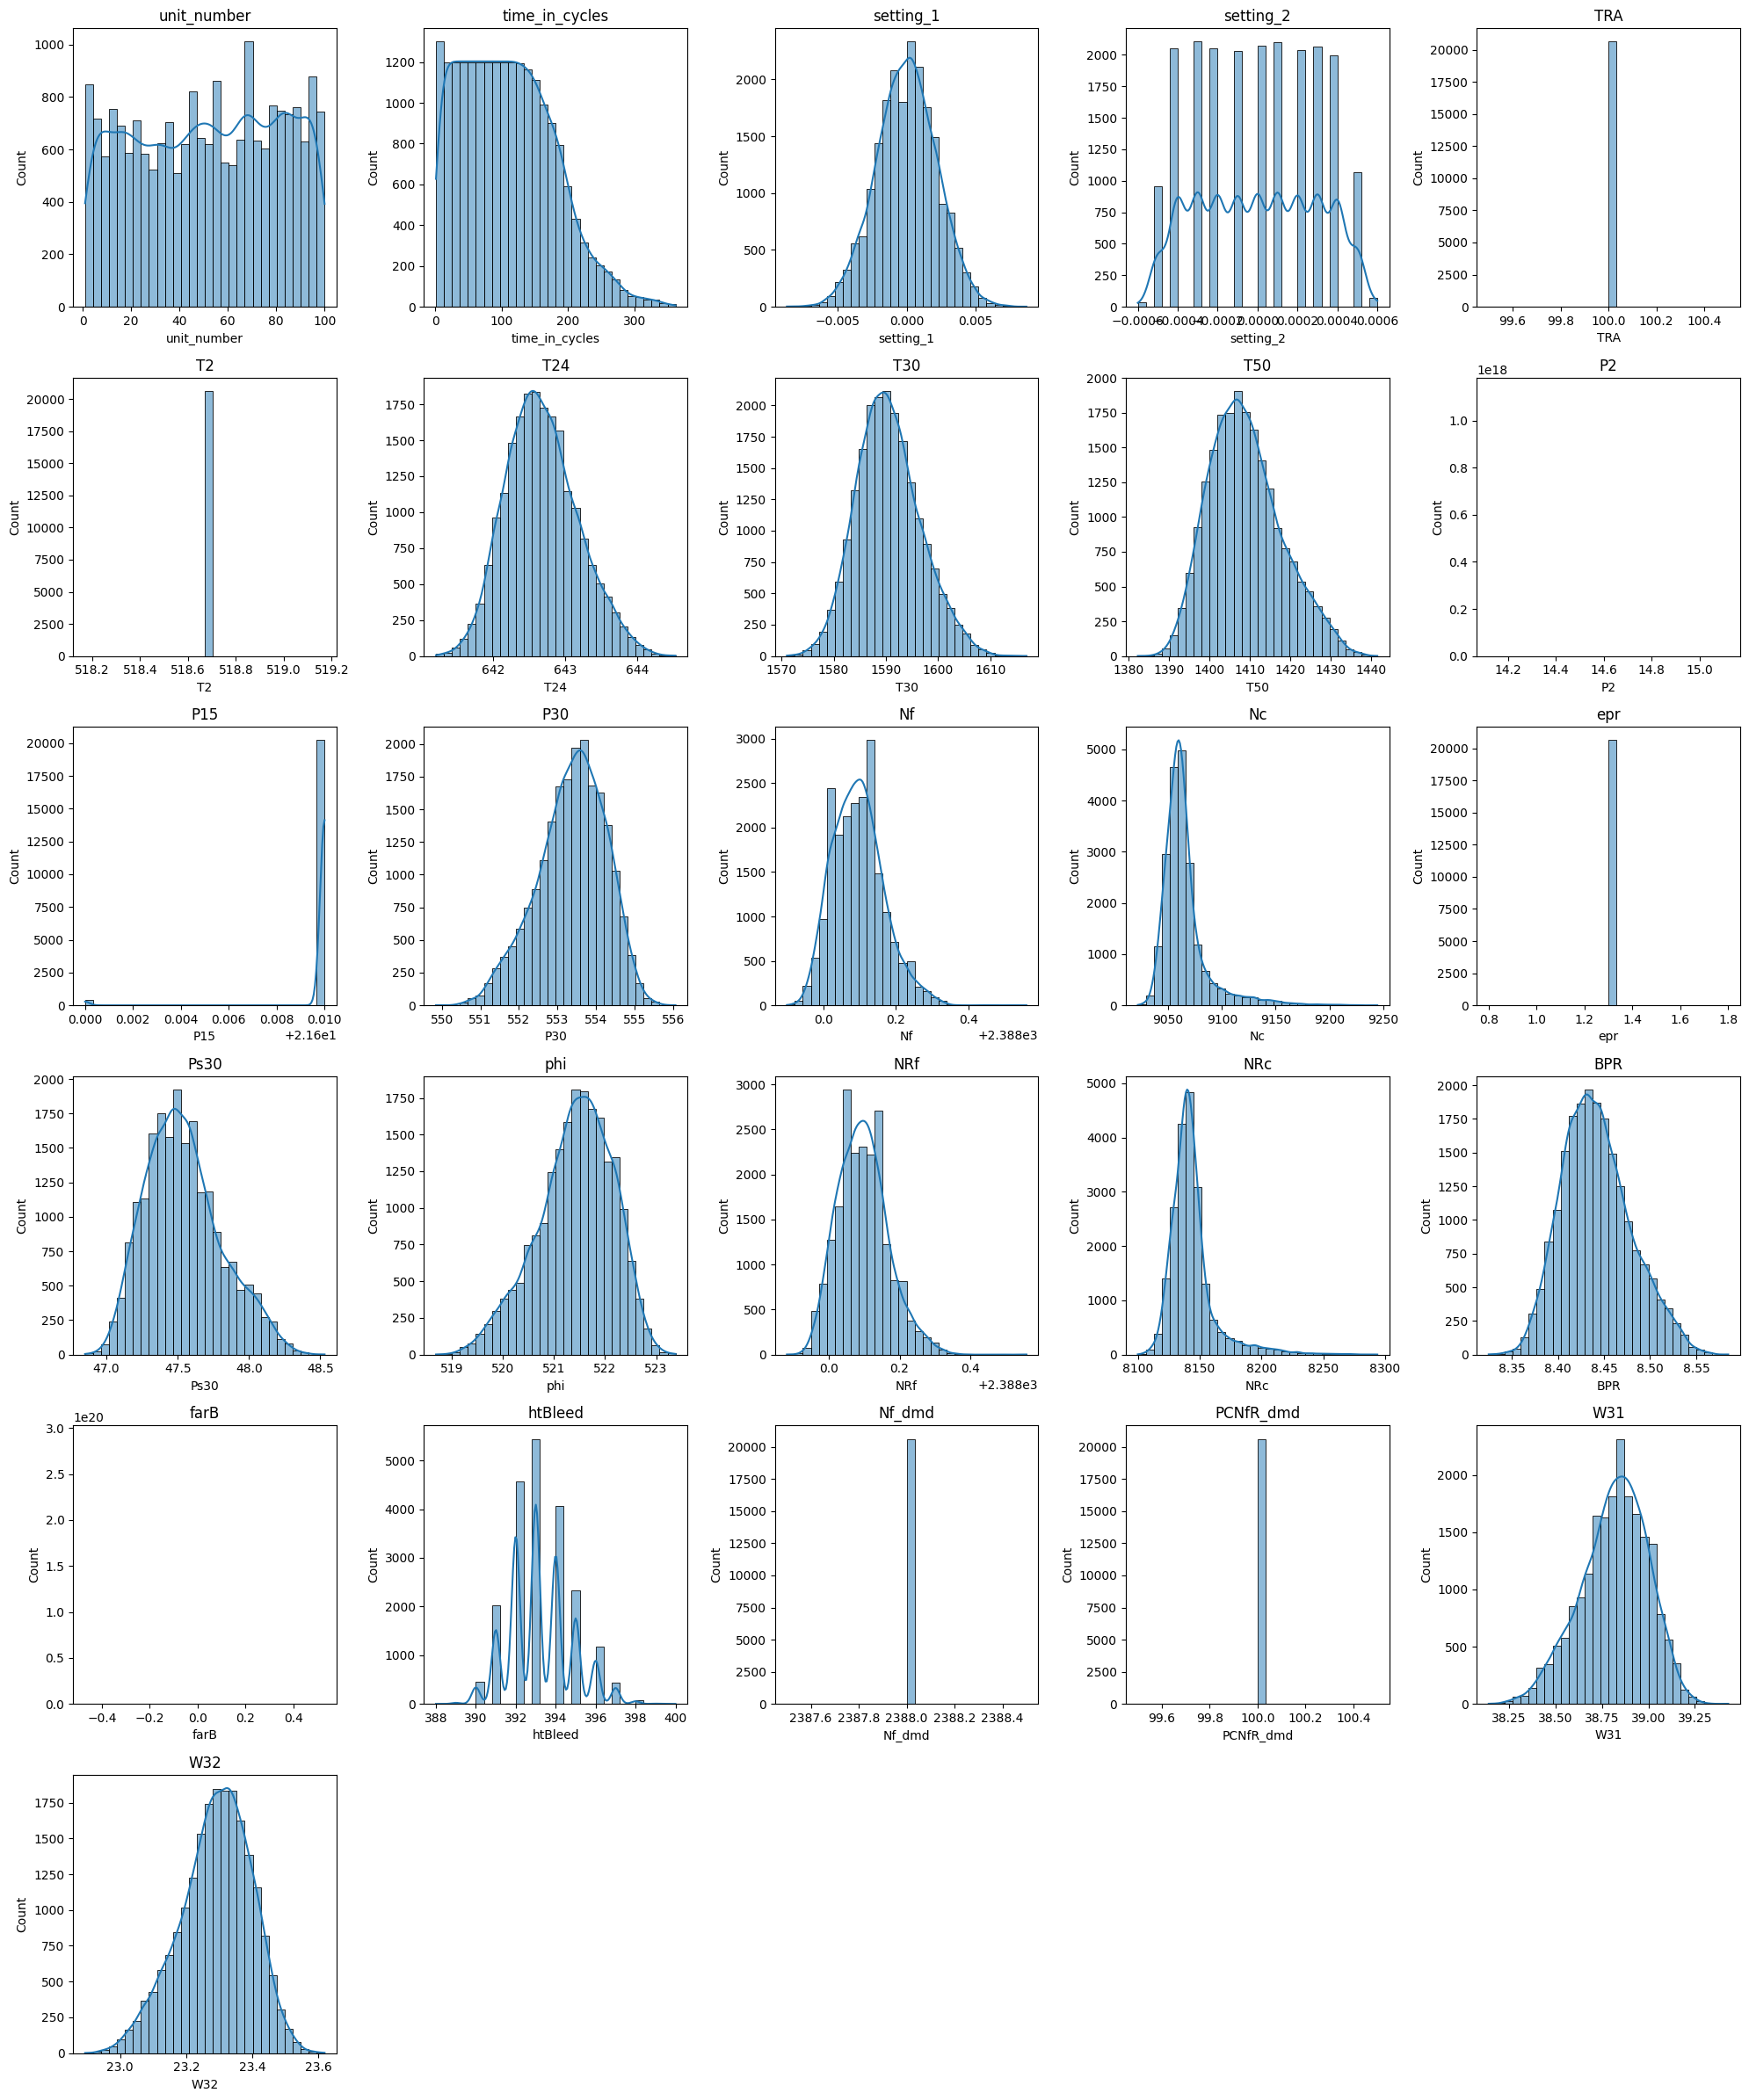

In [11]:
# Plot histograms for each column
import math

cols = fd_001_train.columns
n_cols = 5  # graphs per row
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, col in enumerate(cols):
    sns.histplot(fd_001_train[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{col}')

# Hide extra empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [13]:
#delete columns with constant values ​​that do not carry information about the state of the unit
fd_001_train.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)

We will display the mutual correlations of the signs on the "heat map", for this we will prepare an additional sign "RUL", showing the number of cycles to failure in the training data¶

In [16]:
fd_001_train['life_ratio'] = fd_001_train['time_in_cycles'] / fd_001_train.groupby('unit_number')['time_in_cycles'].transform('max') 
fd_001_train.head()

,unit_number,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.005208
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.010417
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.015625
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.020833
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.026042


In [18]:
fd_001_train[fd_001_train['unit_number']==5]

,unit_number,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
847,5,1,0.0031,0.0002,641.77,1583.59,1395.26,21.61,554.39,2387.98,9066.49,47.19,522.34,2388.00,8152.22,8.4102,393,38.98,23.4468,0.003717
848,5,2,0.0002,0.0003,642.42,1589.69,1394.88,21.61,555.57,2388.01,9063.03,47.09,522.60,2387.99,8153.04,8.4053,392,39.12,23.4075,0.007435
849,5,3,0.0002,-0.0005,642.07,1582.45,1396.29,21.61,554.49,2388.01,9068.21,47.11,522.85,2388.02,8148.42,8.3990,393,39.18,23.3298,0.011152
850,5,4,0.0017,-0.0004,642.08,1586.84,1397.94,21.61,555.16,2387.96,9070.56,47.29,522.11,2387.99,8148.81,8.3876,390,39.22,23.4306,0.014870
851,5,5,-0.0007,0.0001,642.03,1581.45,1394.28,21.61,554.59,2387.98,9069.25,47.09,522.60,2387.95,8147.69,8.4129,390,39.17,23.3331,0.018587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,5,265,0.0028,-0.0003,643.80,1605.53,1424.57,21.61,551.37,2388.16,9148.96,48.03,519.80,2388.10,8203.89,8.5410,395,38.35,23.0857,0.985130
1112,5,266,0.0000,-0.0002,643.38,1609.33,1434.40,21.61,552.35,2388.20,9147.43,48.24,519.57,2388.14,8208.49,8.5254,398,38.55,23.1621,0.988848
1113,5,267,0.0018,0.0001,643.73,1609.41,1430.25,21.61,551.55,2388.10,9147.65,48.26,519.66,2388.17,8206.86,8.5292,397,38.49,23.0566,0.992565
1114,5,268,0.0033,-0.0002,644.02,1608.65,1434.59,21.61,552.22,2388.15,9146.01,48.15,520.10,2388.14,8215.19,8.5196,397,38.52,23.1180,0.996283


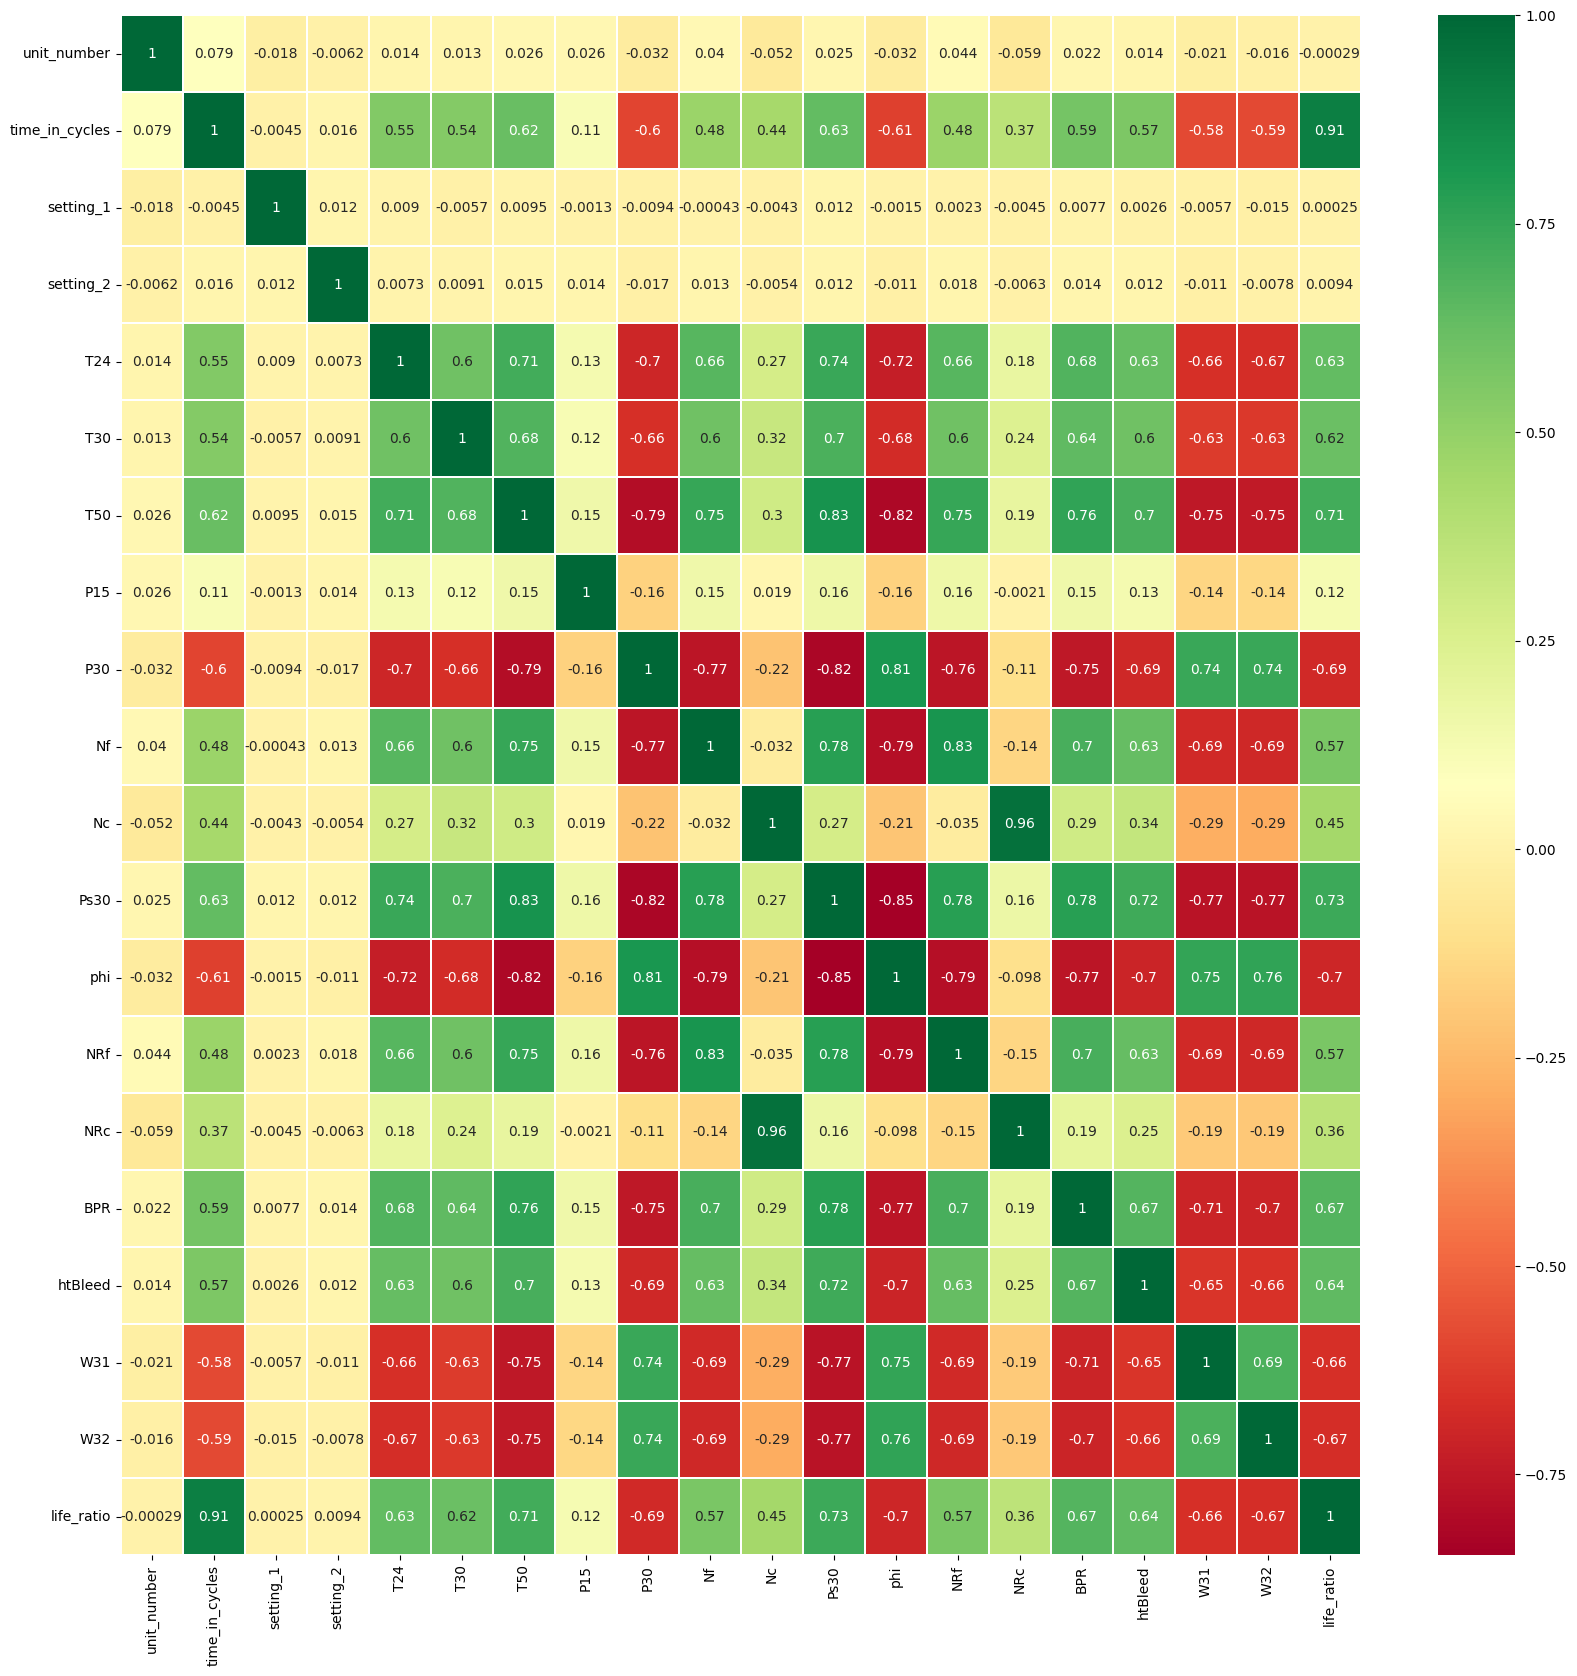

In [19]:
sns.heatmap(fd_001_train.corr(),annot=True,cmap='RdYlGn',linewidths=0.2)
fig=plt.gcf()
fig.set_size_inches(20,20)
plt.show()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [21]:

# Drop non-predictive columns
X = fd_001_train.drop(columns=['unit_number', 'setting_1', 'setting_2', 'life_ratio'])
y = fd_001_train['life_ratio']
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train RandomForest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 0.0036294069131673013


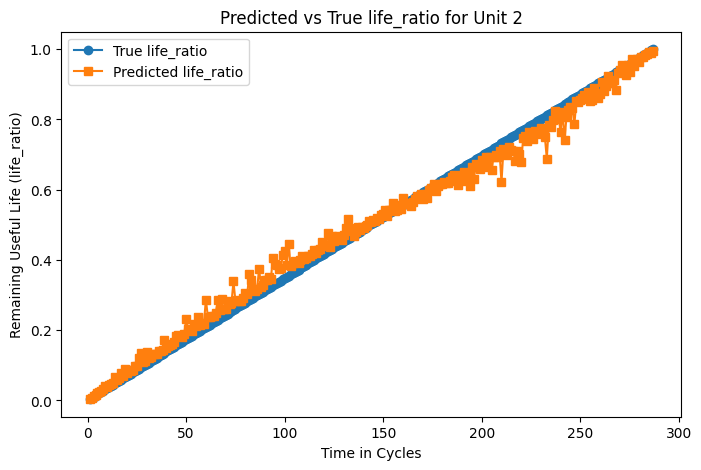

In [23]:

# Plot predicted vs true life_ratio for a specific unit_number
unit_id = fd_001_train['unit_number'].unique()[1]  # Select the first unit_number
unit_data = fd_001_train[fd_001_train['unit_number'] == unit_id]
true_life_ratio = unit_data['life_ratio']
pred_life_ratio = model.predict(unit_data.drop(columns=['unit_number', 'setting_1', 'setting_2', 'life_ratio']))

plt.figure(figsize=(8, 5))
plt.plot(unit_data['time_in_cycles'], true_life_ratio, label='True life_ratio', marker='o')
plt.plot(unit_data['time_in_cycles'], pred_life_ratio, label='Predicted life_ratio', marker='s')
plt.xlabel('Time in Cycles')
plt.ylabel('Remaining Useful Life (life_ratio)')
plt.title(f'Predicted vs True life_ratio for Unit {unit_id}')
plt.legend()
plt.show()

Test on other datasets

In [27]:
fd_001_test_rul = pandas.read_csv(r"C:\Users\Omkar\OneDrive\Desktop\UPSKILLS\Project-6\Turbofan engine\test_FD001.txt",sep=" ",header=None)
fd_001_test_rul.drop(columns=[1],inplace=True)

eol = []
for un in fd_001_test['unit_number'].unique():
    temp_data = fd_001_test[fd_001_test['unit_number'] == un]
    eol_temp = fd_001_test_rul.iloc[un-1].values[0]
    eol_temp_list = [eol_temp for i in range(len(temp_data))]

    eol.extend(eol_temp_list)

In [30]:

from turtle import pd


fd_001_test = pandas.read_csv(r"C:\Users\Omkar\OneDrive\Desktop\UPSKILLS\Project-6\Turbofan engine\test_FD001.txt",sep=" ",header=None)
fd_001_test.drop(columns=[26,27],inplace=True)
columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
           'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]

fd_001_test.columns = columns
fd_001_test.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)
fd_001_test['life_ratio'] = fd_001_test['time_in_cycles'].values / (fd_001_test.groupby('unit_number')['time_in_cycles'].transform('max').values + eol)  

fd_001_test.head()

,unit_number,time_in_cycles,setting_1,setting_2,T24,T30,T50,P15,P30,Nf,Nc,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,1,1,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392,38.86,23.3735,0.03125
1,1,2,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393,39.02,23.3916,0.06250
2,1,3,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393,39.08,23.4166,0.09375
3,1,4,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391,39.00,23.3737,0.12500
4,1,5,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390,38.99,23.4130,0.15625


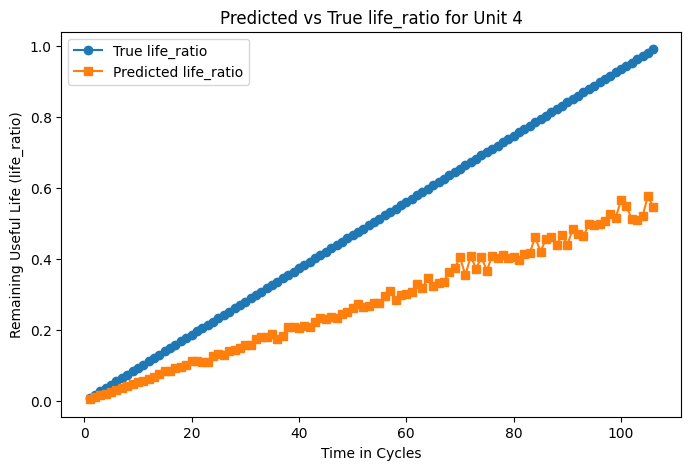

In [31]:
# Plot predicted vs true life_ratio for a specific unit_number
unit_id = fd_001_test['unit_number'].unique()[3]  # Select the first unit_number
unit_data = fd_001_test[fd_001_test['unit_number'] == unit_id]
true_life_ratio = unit_data['life_ratio']
pred_life_ratio = model.predict(unit_data.drop(columns=['unit_number', 'setting_1', 'setting_2', 'life_ratio']))

plt.figure(figsize=(8, 5))
plt.plot(unit_data['time_in_cycles'], true_life_ratio, label='True life_ratio', marker='o')
plt.plot(unit_data['time_in_cycles'], pred_life_ratio, label='Predicted life_ratio', marker='s')
plt.xlabel('Time in Cycles')
plt.ylabel('Remaining Useful Life (life_ratio)')
plt.title(f'Predicted vs True life_ratio for Unit {unit_id}')
plt.legend()
plt.show()

In [34]:
test_data_processed = []

for idx in range(1,5):

    test_data_life_ratio = pandas.read_csv(rf"C:\Users\Omkar\OneDrive\Desktop\UPSKILLS\Project-6\Turbofan engine\RUL_FD00{idx}.txt",sep=" ",header=None)
    test_data = pandas.read_csv(rf"C:\Users\Omkar\OneDrive\Desktop\UPSKILLS\Project-6\Turbofan engine\test_FD00{idx}.txt",sep=" ",header=None)


    test_data.drop(columns=[26,27],inplace=True)
    columns = ['unit_number','time_in_cycles','setting_1','setting_2','TRA','T2','T24','T30','T50','P2','P15','P30','Nf',
            'Nc','epr','Ps30','phi','NRf','NRc','BPR','farB','htBleed','Nf_dmd','PCNfR_dmd','W31','W32' ]

    test_data.columns = columns
    test_data.drop(columns=['Nf_dmd','PCNfR_dmd','P2','T2','TRA','farB','epr'],inplace=True)

    eol = []
    for un in test_data['unit_number'].unique():
        temp_data = test_data[test_data['unit_number'] == un]
        eol_temp = test_data_life_ratio.iloc[un-1].values[0]
        eol_temp_list = [eol_temp for i in range(len(temp_data))]

        eol.extend(eol_temp_list)


    test_data['life_ratio'] = test_data['time_in_cycles'].values / (test_data.groupby('unit_number')['time_in_cycles'].transform('max').values + eol) 
    test_data.drop(columns=['unit_number', 'setting_1', 'setting_2'],inplace=True)

    test_data_processed.append(test_data)

    print(f"Processed test_FD00{idx}.txt, number of rows: {test_data.shape[0]}")
test_data_processed = pandas.concat(test_data_processed, ignore_index=True)

X_test = test_data_processed.drop(columns=['life_ratio'])
y_test = test_data_processed['life_ratio']

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Processed test_FD001.txt, number of rows: 13096
Processed test_FD002.txt, number of rows: 33991
Processed test_FD003.txt, number of rows: 16596
Processed test_FD004.txt, number of rows: 41214
Mean Squared Error: 0.00957350191017222
